# 03: Domains, sensitivity, the detector, and the `AnalysisContainer`

**Development-stack notebook (LATW `dev` branch).** There is no Colab
button here: these tutorials target the *development* versions of the LISA
Analysis Tools packages. Set the environment up by cloning LISAanalysistools
and running its installer (it lays every sibling repo out side by side and
editable-installs the development branches):

```bash
git clone https://github.com/lisa-analysis-tools/lisa-analysis-tools.git LISAanalysistools
bash LISAanalysistools/install.sh
```

For the workshop on the **pip-released** packages, use the
[`main` branch](https://github.com/lisa-analysis-tools/LATW/tree/main) instead
(branch policy: `main` ↔ pip releases, `dev` ↔ the `install.sh` stack).

In [1]:
import os

# Threading is pinned to 1 everywhere in this workshop (MPI-only policy;
# OMP-threaded kernels have caused out-of-memory kills on laptops).
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from copy import deepcopy
from lisatools.utils.constants import *

# The stock LISA noise models evaluate 1/f terms at f = 0 on full FFT grids;
# those bins are masked downstream, so silence the numpy divide warnings.
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Slightly larger default text so labels/ticks/titles read clearly in the
# rendered figures.
plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
                     "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11})


In this tutorial we build up the **data-analysis spine** of `lisatools`,
one layer at a time, from the bottom of the dependency stack in
[`00`](00_SetupAndAtlas.ipynb):

1. **`lisatools.domains`** — signal arrays that know what basis they live in
   (time, frequency, time-frequency) and can transform between them.
2. **`lisatools.sensitivity`** — the LISA noise model: sensitivity curves and
   the channel covariance (PSD/CSD) matrix that weights every inner product.
3. **`lisatools.detector`** — the orbits and instrument-noise models the
   sensitivity is built from.
4. **`lisatools.analysiscontainer.AnalysisContainer`** — the object that ties
   *data + noise + a signal generator* together and hands you an SNR, an inner
   product, and a likelihood.

The through-line is *small → large*: the very same objects that score one
source scale up to hold every residual of the global fit
([`03`](03_StockGlobalFitsInDepth.ipynb)).

**How to read this notebook.** Casual readers can follow the `##` section
headers and their **TL;DR** cells and run the one minimal cell under each.
Pipeline developers should also read the **"Going deeper"** subsections —
those carry the internals you need when you build your own analysis.

## Domains — one signal, many bases

**TL;DR.** `lisatools.domains` gives you basis-tagged signal arrays —
`TDSignal` (time), `FDSignal` (frequency), `STFTSignal` and `WDMSignal`
(time-frequency) — each paired with a `*Settings` object that records the
grid. A signal always knows its basis and transforms itself: `.fft()`,
`.stft()`, `.wdmtransform()`. This is the object the whole stack passes around;
never reach for the deprecated data-residual shim (the do-not-use list in
[`00`](00_SetupAndAtlas.ipynb)) — always use these `DomainBase` classes
directly.

TD (1, 32768)  -> FD (1, 16385)  -> WDM (1, 64, 512) (nchan, Nf, Nt)


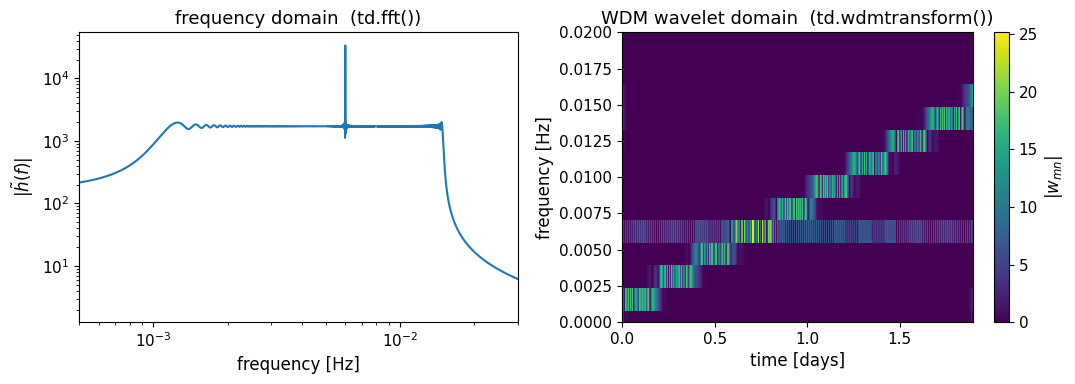

In [2]:
from lisatools.domains import TDSettings, TDSignal, WDMSettings

dt = 5.0                       # time-domain sample spacing [s]
Nf, Nt = 64, 512               # WDM grid: Nf frequency layers x Nt time pixels
N = Nf * Nt                    # the WDM transform needs exactly Nf*Nt TD samples
t = np.arange(N) * dt
Tobs = N * dt

# a linear chirp (1 -> 15 mHz) plus a steady 6 mHz tone, shape (nchannels, N)
flo, fhi = 1e-3, 1.5e-2
h = np.sin(2 * np.pi * (flo * t + 0.5 * (fhi - flo) / Tobs * t ** 2))
h = h + 0.4 * np.sin(2 * np.pi * 6e-3 * t)

td = TDSignal(h[None, :], TDSettings(N=N, dt=dt, force_backend="cpu"))
fd = td.fft()                                                  # -> FDSignal
wdm = td.wdmtransform(settings=WDMSettings(Nf=Nf, Nt=Nt, dt=dt, force_backend="cpu"))

print("TD", td.shape, " -> FD", fd.shape, " -> WDM", wdm.arr.shape, "(nchan, Nf, Nt)")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
a0.loglog(np.asarray(fd.f_arr), np.abs(np.asarray(fd.arr[0])))
a0.set(xlabel="frequency [Hz]", ylabel=r"$|\tilde{h}(f)|$",
       title="frequency domain  (td.fft())", xlim=(5e-4, 3e-2))
# WDM coefficients |w_{mn}| on the (time, frequency) wavelet grid
im = a1.pcolormesh(np.asarray(wdm.t_arr) / 86400.0, np.asarray(wdm.f_arr),
                   np.abs(np.asarray(wdm.arr[0])), shading="auto")
a1.set(xlabel="time [days]", ylabel="frequency [Hz]",
       title="WDM wavelet domain  (td.wdmtransform())", ylim=(0, 2e-2))
fig.colorbar(im, ax=a1, label=r"$|w_{mn}|$")
fig.tight_layout()
plt.show()

### Going deeper: the WDM wavelet grid

The WDM (Wilson–Daubechies–Meyer) transform tiles the time–frequency plane
into `Nf` frequency **layers** by `Nt` time **pixels**. Two numbers set the
grid, and everything else follows (this is the same wavelet basis the global
fit uses for the fast narrow-band GB and SOBHB likelihoods —
see [`03`](03_StockGlobalFitsInDepth.ipynb)):

- `layer_df = 1 / (2 * Nf * dt)` — the frequency spacing between layers.
- `layer_dt = Nf * dt` — the duration of one time pixel.

so `layer_df * layer_dt = 1/2`: buying finer frequency resolution costs you
time resolution, exactly at the critical-sampling limit. Two hard constraints
follow, and the transform will not silently paper over either:

- the TD signal must be **exactly `Nf * Nt` samples long** (no auto-padding);
- `Nf` and `Nt` must both be **even**.

`STFTSignal`/`STFTSettings` are the other time-frequency option (a windowed
short-time FFT rather than a critically-sampled wavelet basis); build one with
`td.stft(settings=...)`. Full derivations are in LAT's
`examples/wdm_transform_tutorial.ipynb` and
`examples/time_frequency_domains_tutorial.ipynb`.

In [3]:
ws = WDMSettings(Nf=Nf, Nt=Nt, dt=dt, force_backend="cpu")
print(f"Nf (frequency layers)     = {ws.Nf}")
print(f"Nt (time pixels)          = {ws.Nt}")
print(f"N  = Nf * Nt (TD samples) = {ws.N}   (matches len(h) = {N})")
print(f"layer_df = 1/(2*Nf*dt)    = {ws.layer_df:.4e} Hz")
print(f"layer_dt = Nf*dt          = {ws.layer_dt:.1f} s")
print(f"layer_df * layer_dt       = {ws.layer_df * ws.layer_dt:.3f}   (critical sampling: 1/2)")
print(f"Nyquist = Nf*layer_df     = {ws.Nf * ws.layer_df:.4f} Hz = 1/(2*dt) = {1/(2*dt):.4f} Hz")

Nf (frequency layers)     = 64
Nt (time pixels)          = 512
N  = Nf * Nt (TD samples) = 32768   (matches len(h) = 32768)
layer_df = 1/(2*Nf*dt)    = 1.5625e-03 Hz
layer_dt = Nf*dt          = 320.0 s
layer_df * layer_dt       = 0.500   (critical sampling: 1/2)
Nyquist = Nf*layer_df     = 0.1000 Hz = 1/(2*dt) = 0.1000 Hz


## Sensitivity — the LISA noise model

**TL;DR.** `lisatools.sensitivity.get_sensitivity` evaluates a noise curve
on a frequency grid and returns it as a `PSD`, `ASD`, or `char_strain`
(`return_type=`). Stock curves include `LISASens` (the sky/polarization-averaged
strain sensitivity) and the per-TDI-channel curves (`X1TDISens`, `A1TDISens`, …).
For a full analysis you need the channel **covariance** — a `SensitivityMatrix`
— which weights every inner product; stock builders like `XYZ2SensitivityMatrix`
assemble it for you.

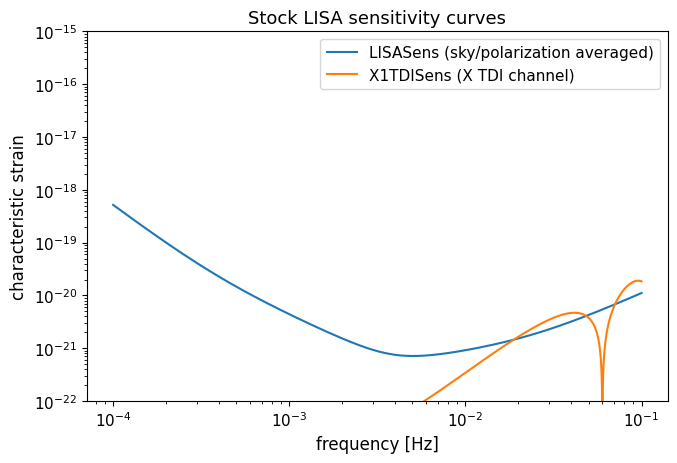

In [4]:
from lisatools.sensitivity import get_sensitivity, LISASens, X1TDISens
from lisatools.domains import FDSettings

# LISASens on a raw frequency array (the back-compat path still accepts one)
f = np.logspace(-4, -1, 3000)
hc_lisa = get_sensitivity(f, sens_fn=LISASens, return_type="char_strain")

# a TDI channel on an FD grid (the settings-first API): pass FDSettings, get
# the curve back on its f_arr. We use the X channel (workshop default: XYZ).
fd_grid = FDSettings(N=8001, df=1.25e-5, min_freq=1e-4, max_freq=1e-1, force_backend="cpu")
hc_X = get_sensitivity(fd_grid, sens_fn=X1TDISens, return_type="char_strain")

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.loglog(f, hc_lisa, label="LISASens (sky/polarization averaged)")
ax.loglog(np.asarray(fd_grid.f_arr), hc_X, label="X1TDISens (X TDI channel)")
ax.set(xlabel="frequency [Hz]", ylabel="characteristic strain",
       title="Stock LISA sensitivity curves", ylim=(1e-22, 1e-15))
ax.legend()
plt.show()

### Going deeper: the channel covariance `SensitivityMatrix`

A single curve is enough to eyeball a source, but the likelihood needs the
full **channel covariance** at every frequency. The three TDI channels X, Y, Z
share noise sources (each arm feeds two channels), so their covariance is a
dense `3 x 3` Hermitian matrix per frequency — PSDs on the diagonal, cross
spectra (CSDs) off it. `XYZ2SensitivityMatrix` (TDI-2) builds it and exposes
the two things the Gaussian likelihood consumes: `invC` (the inverse
covariance that weights inner products) and `detC` (its determinant, the noise
normalization).

You will also hear about the **A, E, T** channels: they are orthogonal linear
combinations of X, Y, Z that *diagonalize* this covariance (A and E carry the
GW-sensitive signal, T is a near-null noise monitor). They are handy for
back-of-envelope work, but the stock global fit runs in **XYZ** and carries
the full covariance — so that is what we use throughout the workshop. See
LAT's `examples/Sensitivity.ipynb` for the model knobs (`model=`,
`stochastic_params=`).

matrix shape (chan x chan x freq): (3, 3, 7993)
invC: (3, 3, 7993)   detC: (7993,)


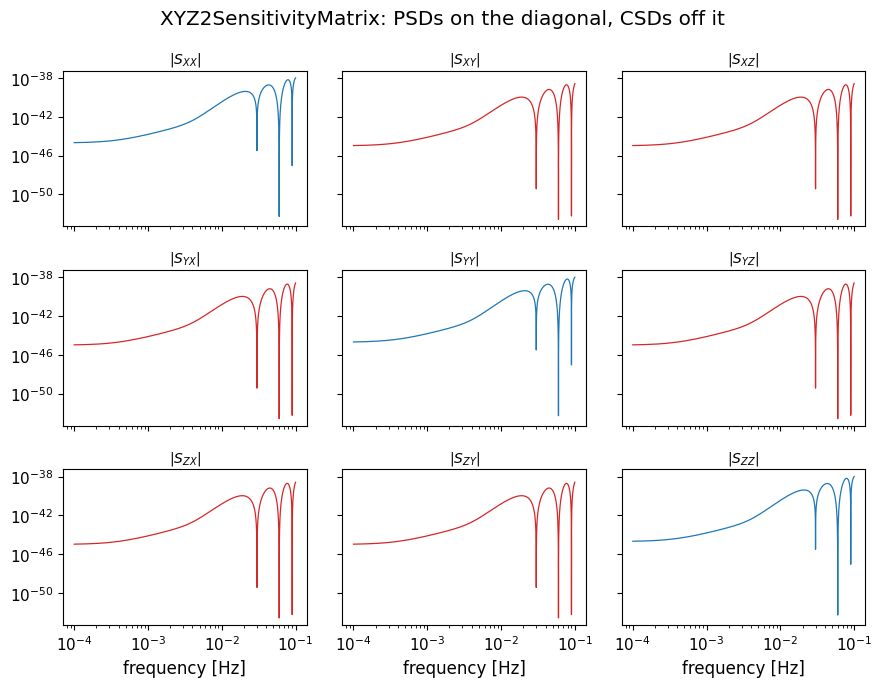

In [5]:
from lisatools.sensitivity import XYZ2SensitivityMatrix

sens = XYZ2SensitivityMatrix(fd_grid, model="sangria")   # 3x3 Hermitian, TDI-2
print("matrix shape (chan x chan x freq):", sens.shape)
print("invC:", sens.invC.shape, "  detC:", sens.detC.shape)

ch = "XYZ"
fig, axes = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(9, 7))
ff = np.asarray(fd_grid.f_arr)
for i in range(3):
    for j in range(3):
        axes[i, j].loglog(ff, np.abs(np.asarray(sens.sens_mat[i, j])),
                          color="C0" if i == j else "C3", lw=0.9)
        axes[i, j].set_title(f"$|S_{{{ch[i]}{ch[j]}}}|$", fontsize=10)
for j in range(3):
    axes[-1, j].set_xlabel("frequency [Hz]")
fig.suptitle("XYZ2SensitivityMatrix: PSDs on the diagonal, CSDs off it")
fig.tight_layout()
plt.show()

## The detector — orbits and noise models

**TL;DR.** `lisatools.detector` holds the geometry and instrument the noise
model is built from: `Orbits`/`EqualArmlengthOrbits` give spacecraft positions
and light-travel times along each link, and a `LISAModel` bundles the two noise
levels (`Soms_d` optical-metrology, `Sa_a` test-mass acceleration) with an
orbit. `get_available_default_lisa_models()` lists the stock models.

In [6]:
from lisatools.detector import (EqualArmlengthOrbits,
    get_available_default_lisa_models, get_default_lisa_model_from_str)

C_LIGHT = 299792458.0  # m/s
orbits = EqualArmlengthOrbits(force_backend="cpu")

# light-travel time along link 12 (spacecraft 2 -> 1), sampled at a few times
tt = np.array([0.0, 1.0e6, 2.0e6])
ltt = np.asarray(orbits.get_light_travel_times(tt, 12))
print("light travel time, link 12 [s]:", ltt)
print("=> armlength [Gm]:", ltt * C_LIGHT / 1e9, " (LISA arm ~ 2.5 Gm)")

print("\nstock LISA models:", [m.name for m in get_available_default_lisa_models()])
m = get_default_lisa_model_from_str("scirdv1")
print(f"scirdv1: Soms_d = {m.Soms_d:.3e},  Sa_a = {m.Sa_a:.3e}")

light travel time, link 12 [s]: [8.33951863 8.33965236 8.33976443]
=> armlength [Gm]: [2.50012479 2.50016488 2.50019848]  (LISA arm ~ 2.5 Gm)

stock LISA models: ['scirdv1', 'proposal', 'mrdv1', 'sangria', 'sangria_v2']
scirdv1: Soms_d = 2.250e-22,  Sa_a = 9.000e-30


## The `AnalysisContainer` — SNR and likelihood for one source

**TL;DR.** `AnalysisContainer(data, sens_mat)` ties a data/residual signal
(a `DomainBase`, e.g. an `FDSignal`) to a `SensitivityMatrix` and gives you the
core scores: `.snr()`, `.inner_product()` (`<d|d>`), and `.likelihood()`. Hand
it a template with `.template_snr(h)` / `.template_likelihood(h)`, or wire in a
`signal_gen` callable to score straight from parameters. This is the atom of
every LISA analysis in the stack.

<d|d>            = 3472.5723
optimal SNR      = 58.9285
logL source-only = -1736.2862   (= -<d|d>/2)
template SNR (opt, det): (58.929, 58.929)


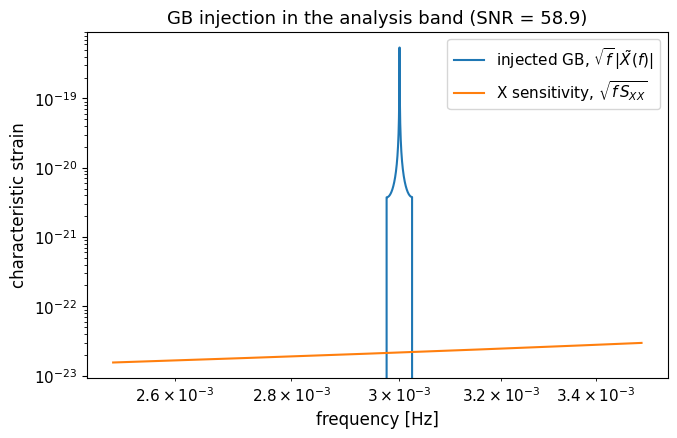

In [7]:
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.detector import EqualArmlengthOrbits
from lisatools.domains import FDSignal
from gbgpu.gbgpu import GBGPU

# --- inject one Galactic binary as TDI-2 XYZ on a full rFFT grid -------------
dt = 10.0
Nf_w, Nt_w = 256, 2048
Ng = Nf_w * Nt_w
Tg = Ng * dt
data_length = Ng // 2 + 1
df = 1.0 / Tg

gb = GBGPU(force_backend="cpu", orbits=EqualArmlengthOrbits(force_backend="cpu"))
gb.gpus = None  # generate_global_template reads this; None = CPU

# amp, f0, fdot, phi0, iota, psi, ecliptic lon, ecliptic lat
truth = np.array([2e-22, 3.0e-3, 1.0e-17, 0.3, 0.7, 1.2, 2.0, 0.5])

def gb_fd_xyz(A, f0, fdot, phi0, iota, psi, lam, beta, oversample=4):
    """One GB's TDI-2 XYZ response on the full rFFT grid -> (3, data_length)."""
    params = np.atleast_2d([A, f0, fdot, 0.0, phi0, iota, psi, lam, beta]).astype(np.float64)
    buf = np.zeros(3 * data_length, dtype=np.complex128)
    gb.generate_global_template(params, np.zeros(params.shape[0], dtype=np.int32), buf,
        start_freq_ind=0, T=Tg, dt=dt, tdi_channel_setup="XYZ", tdi2=True,
        oversample=oversample, data_length=data_length)
    return buf.reshape(3, data_length)

injection = gb_fd_xyz(*truth)

# --- band-limit the data + build the XYZ covariance on that band -------------
fd_band = FDSettings(N=data_length, df=df, min_freq=2.5e-3, max_freq=3.5e-3, force_backend="cpu")
data = FDSignal(injection.copy(), fd_band)             # auto-sliced to the band
sens = XYZ2SensitivityMatrix(fd_band, model="sangria")

ac = AnalysisContainer(data, sens)                     # <-- the atom
print(f"<d|d>            = {ac.inner_product():.4f}")
print(f"optimal SNR      = {ac.snr():.4f}")
print(f"logL source-only = {ac.likelihood(source_only=True):.4f}   (= -<d|d>/2)")

# a perfect template recovers the full SNR (opt, det); an off-source one does not
h_true = FDSignal(gb_fd_xyz(*truth), fd_band)
print("template SNR (opt, det):", tuple(round(float(x), 3) for x in ac.template_snr(h_true)))

# --- see the injection against the noise -------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.5))
fb = np.asarray(fd_band.f_arr)
ax.loglog(fb, np.sqrt(fb) * np.abs(np.asarray(data[0])), label=r"injected GB, $\sqrt{f}\,|\tilde X(f)|$")
ax.loglog(fb, np.sqrt(fb * np.abs(np.asarray(sens[(0, 0)]))), label=r"X sensitivity, $\sqrt{f\,S_{XX}}$")
ax.set(xlabel="frequency [Hz]", ylabel="characteristic strain",
       title=f"GB injection in the analysis band (SNR = {ac.snr():.1f})")
ax.legend()
plt.show()

### Going deeper: information matrix information and covariance

Before running a full sampler you often want a cheap forecast of how well a
source is measured. The **information matrix** (information matrix)
`M_ij = <\partial_i h | \partial_j h>` does that: its inverse is the parameter
covariance, and the `1\sigma` errors are the square roots of that covariance's
diagonal. `lisatools.diagnostic` provides `info_matrix`, `covariance`, and
`plot_covariance_corner`. Here we use a cheap analytic 3-parameter
frequency-domain "line" model so the whole thing runs in a blink; swap in any
`waveform_model(*params, *waveform_args) -> channels` callable for a real
forecast.

information matrix:
 [[ 3.042 -0.058  0.307]
 [-0.058  0.061 -0.017]
 [ 0.307 -0.017  0.092]]

1-sigma errors [ln A, f0 mHz, sigma mHz]: [0.70303287 4.14291068 4.10094381]


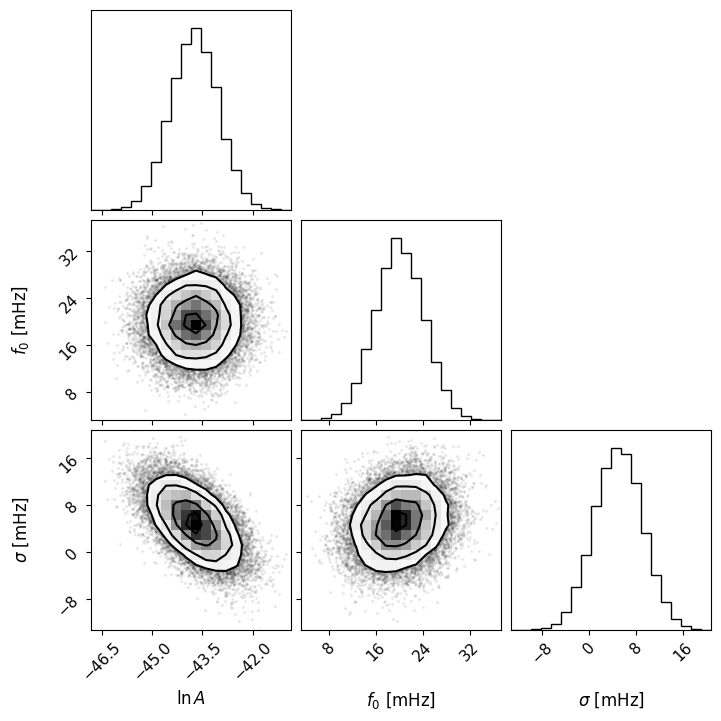

In [8]:
from lisatools.diagnostic import info_matrix, covariance, plot_covariance_corner

fd_fish = FDSettings(N=4096, df=2.5e-5, min_freq=2e-3, max_freq=6e-2, force_backend="cpu")
f_fish = np.asarray(fd_fish.f_arr)

def line_model(lnA, f0_mHz, sig_mHz, f):
    """A Gaussian spectral line: amplitude exp(lnA), centre f0, width sigma."""
    A, f0, sig = np.exp(lnA), f0_mHz * 1e-3, sig_mHz * 1e-3
    return A * np.exp(-0.5 * ((f - f0) / sig) ** 2) + 0.0j

params = np.array([np.log(1e-19), 20.0, 5.0])   # [ln A, f0 (mHz), sigma (mHz)]

im = info_matrix(1e-6, line_model, params,
                 inner_product_kwargs=dict(basis_settings=fd_fish, psd="LISASens"),
                 waveform_args=(f_fish,))
cov = covariance(info_mat=im)
print("information matrix:\n", np.array_str(im, precision=3))
print("\n1-sigma errors [ln A, f0 mHz, sigma mHz]:", np.sqrt(np.diag(cov)))

plot_covariance_corner(params, cov,
    labels=[r"$\ln A$", r"$f_0$ [mHz]", r"$\sigma$ [mHz]"])
plt.show()

## From one source to the whole global fit

Everything above scored **one** source. An `AnalysisContainer` holds a
single residual + its noise covariance + (optionally) one signal generator —
one SNR, one likelihood.

The global fit has thousands of overlapping sources across many frequency
bands, so it holds **many** of these atoms at once in an
`AnalysisContainerArray` (from `lisatools.analysiscontainer`): a batched
collection of `AnalysisContainer`s, typically one per band or per source, that
can score them together and split the work across GPUs/ranks. That array is
exactly how the stock global fit stores and updates every residual as the
sampler runs.

That is the *small → large* payoff: the atom you just used to compute a single
GB's SNR is the same object the pipeline batches to fit the entire LISA data
stream. Next: [`05`](05_ResponseAndTDI.ipynb) shows where the TDI data these
containers score actually comes from; [`03`](03_StockGlobalFitsInDepth.ipynb)
runs the full global fit.